<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

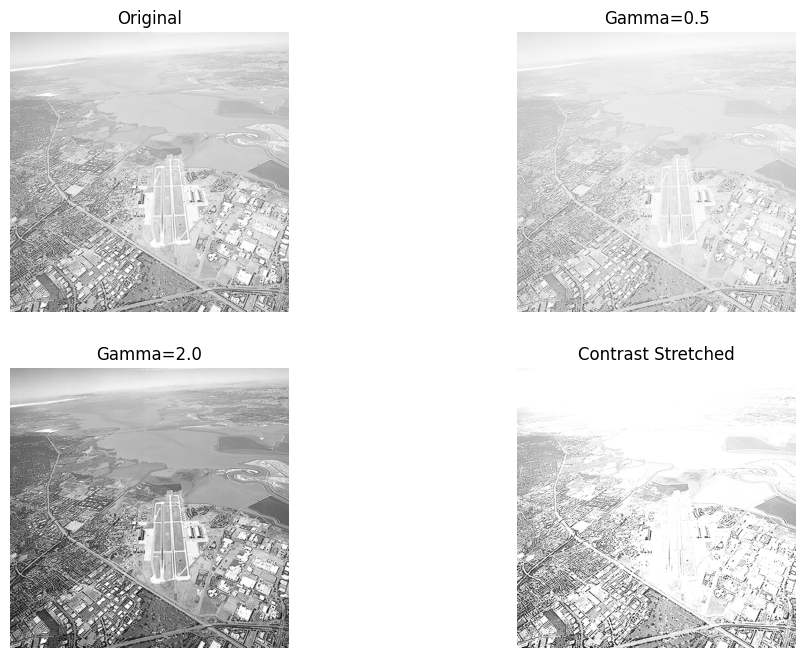

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD THE IMAGE
img = cv.imread('/content/drive/MyDrive/Assignment1/runway.png', cv.IMREAD_GRAYSCALE)

# 2. GAMMA CORRECTION
gamma_val_a = 0.5
t_gamma_a = np.array([(i / 255.0) ** gamma_val_a * 255
                      for i in np.arange(0, 256)]).astype(np.uint8).reshape(1, 256)
img_gamma_a = cv.LUT(img, t_gamma_a)

gamma_val_b = 2.0
t_gamma_b = np.array([(i / 255.0) ** gamma_val_b * 255
                      for i in np.arange(0, 256)]).astype(np.uint8).reshape(1, 256)
img_gamma_b = cv.LUT(img, t_gamma_b)

# 3. CONTRAST STRETCHING
r1 = int(0.2 * 255)
r2 = int(0.8 * 255)

t1 = np.zeros(r1, dtype=np.uint8)
t2 = np.linspace(0, 255, r2 - r1 + 1).astype(np.uint8)
t3 = np.full(256 - len(t1) - len(t2), 255, dtype=np.uint8)

transform_table = np.concatenate((t1, t2, t3), axis=0).astype(np.uint8).reshape(1, 256)

img_contrast = cv.LUT(img, transform_table)

# 4. VISUALIZATION
plt.figure(figsize=(12, 8))
images = [img, img_gamma_a, img_gamma_b, img_contrast]
titles = ['Original', 'Gamma=0.5', 'Gamma=2.0', 'Contrast Stretched']

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()